# Exploration: induction-head emergence dynamics in Pythia

Three questions:

1. **When do induction heads emerge** in each Pythia size?
2. **How do they accumulate** over training — gradual ramp, sudden jump, stepped pattern?
3. **When does the count saturate** — i.e., at what point do *new* induction heads stop emerging?

**This is exploration, not the pre-registered sweep.** The Phase 2 sweep (`PROJECT_BRIEF.md` §5) uses 40 checkpoints per size from `checkpoints.yaml`. Here we use 6 log-spaced steps per size as a preview, so total wall-clock fits in a single afternoon. The exploration output is saved to `data/exploration/` and is *not* the canonical sweep dataset.

Detector: same Olsson prefix-matching score we validated on Day 1. Sample size reduced to 20 random sequences (vs. 50) for speed; score variance across that many sequences is small enough for the trends we're looking for.

## Setup

In [1]:
import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

import sys, time
from pathlib import Path
REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from src.utils.pythia_loader import load_pythia, prefetch_pythia
from src.detectors.induction import prefix_matching_score

torch.set_grad_enabled(False)

def free_mps_cache():
    if torch.backends.mps.is_available():
        try:
            torch.mps.empty_cache()
        except Exception:
            pass

OUT_DIR = REPO / 'data' / 'exploration'
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PARQUET = OUT_DIR / 'induction_emergence_preview.parquet'

## Sweep configuration

6 checkpoints per size, chosen to bracket the expected emergence transition. Step 0 is initialization; steps 1000–25000 cover the documented Pythia induction-emergence window from Olsson 2022 / Tigges 2024; step 143000 is the final checkpoint.

In [2]:
SIZES = ['70m', '160m', '410m']
CHECKPOINTS = [0, 1000, 3000, 8000, 25000, 143000]
N_SEQUENCES = 20
SEQ_LEN = 100
THRESHOLD_CANDIDATE = 0.3
THRESHOLD_STRONG = 0.5

n_runs = len(SIZES) * len(CHECKPOINTS)
print(f'sweep: {len(SIZES)} sizes x {len(CHECKPOINTS)} checkpoints = {n_runs} runs')
print(f'detector: prefix_matching_score, n_sequences={N_SEQUENCES}, seq_len={SEQ_LEN}')

sweep: 3 sizes x 6 checkpoints = 18 runs
detector: prefix_matching_score, n_sequences=20, seq_len=100


## Prefetch checkpoints

Pull each (size, step) snapshot to the local HF cache. First-time downloads can take several minutes; subsequent calls are no-ops.

In [3]:
t0 = time.time()
for size in SIZES:
    for step in CHECKPOINTS:
        t1 = time.time()
        prefetch_pythia(size, step)
        print(f'  pythia-{size} @ step{step:>6} ready ({time.time() - t1:.1f}s)')
print(f'\nprefetch total: {time.time() - t0:.1f}s')

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

  pythia-70m @ step     0 ready (8.2s)


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

  pythia-70m @ step  1000 ready (8.8s)


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

...

  pythia-410m @ step  8000 ready (36.8s)


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

  pythia-410m @ step 25000 ready (37.2s)


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

  pythia-410m @ step143000 ready (0.1s)

prefetch total: 342.7s


## Run the sweep

For each (size, step), load the model, score every (layer, head) with the induction detector, and append to a long-format DataFrame. Persist to parquet.

In [4]:
if OUT_PARQUET.exists():
    df = pd.read_parquet(OUT_PARQUET)
    print(f'loaded cached results from {OUT_PARQUET.relative_to(REPO)} '
          f'({len(df)} rows)')
else:
    records = []
    t_total = time.time()
    for size in SIZES:
        for step in CHECKPOINTS:
            t1 = time.time()
            model = load_pythia(size, step=step)
            result = prefix_matching_score(
                model, n_sequences=N_SEQUENCES, seq_len=SEQ_LEN
            )
            scores = result.scores.numpy()
            n_layers, n_heads = scores.shape
            for layer in range(n_layers):
                for head in range(n_heads):
                    records.append({
                        'size': size, 'step': int(step),
                        'layer': int(layer), 'head': int(head),
                        'score': float(scores[layer, head]),
                    })
            del model
            free_mps_cache()
            top = scores.max()
            print(f'  pythia-{size} @ step{step:>6}: max score {top:.3f} '
                  f'({time.time() - t1:.1f}s)')
    df = pd.DataFrame(records)
    df.to_parquet(OUT_PARQUET)
    print(f'\nsweep total: {time.time() - t_total:.1f}s '
          f'-> {OUT_PARQUET.relative_to(REPO)} ({len(df)} rows)')

/Users/cberg/Documents/Emergence_Research/pythia-motif-emergence/.venv/lib/python3.12/site-packages/transformer_lens/config/HookedTransformerConfig.py:341: UserWarning: MPS backend may produce silently incorrect results (PyTorch 2.11.0). Set TRANSFORMERLENS_ALLOW_MPS=1 to suppress this warning. See: https://github.com/TransformerLensOrg/TransformerLens/issues/1178
  warn_if_mps(self.device)


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loaded pretrained model EleutherAI/pythia-70m-deduped into HookedTransformer


  pythia-70m @ step     0: max score 0.015 (1.6s)


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

...

Loaded pretrained model EleutherAI/pythia-410m-deduped into HookedTransformer


  pythia-410m @ step 25000: max score 0.955 (2.5s)


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loaded pretrained model EleutherAI/pythia-410m-deduped into HookedTransformer


  pythia-410m @ step143000: max score 0.953 (3.2s)

sweep total: 29.8s -> data/exploration/induction_emergence_preview.parquet (3456 rows)


## Q1+Q2: when do induction heads emerge, and how do they accumulate?

Count of heads above each threshold, plotted against training step. Use a symmetric-log x-axis so step 0 (init) is visible alongside the log-spaced later checkpoints.

In [5]:
counts = (
    df.groupby(['size', 'step'])
      .agg(
          n_above_03=('score', lambda s: (s > THRESHOLD_CANDIDATE).sum()),
          n_above_05=('score', lambda s: (s > THRESHOLD_STRONG).sum()),
          max_score=('score', 'max'),
          mean_score=('score', 'mean'),
      )
      .reset_index()
      .sort_values(['size', 'step'])
)
print(counts.to_string(index=False))

size   step  n_above_03  n_above_05  max_score  mean_score
160m      0           0           0   0.015351    0.013822
160m   1000           6           4   0.973274    0.046922
160m   3000           6           6   0.973024    0.056353
160m   8000           8           6   0.963768    0.071099
160m  25000          10           7   0.932429    0.077007
160m 143000          17           9   0.884065    0.091268
410m      0           0           0   0.016327    0.013770
410m   1000          11           8   0.879476    0.038950
410m   3000          14          10   0.946599    0.046137
410m   8000          20          13   0.943127    0.057450
410m  25000          22          14   0.955097    0.060147
410m 143000          19          11   0.953239    0.051697
 70m      0           0           0   0.015083    0.013864
 70m   1000           6           5   0.953111    0.096575
 70m   3000           5           4   0.977663    0.092493
 70m   8000           5           5   0.975552    0.0999

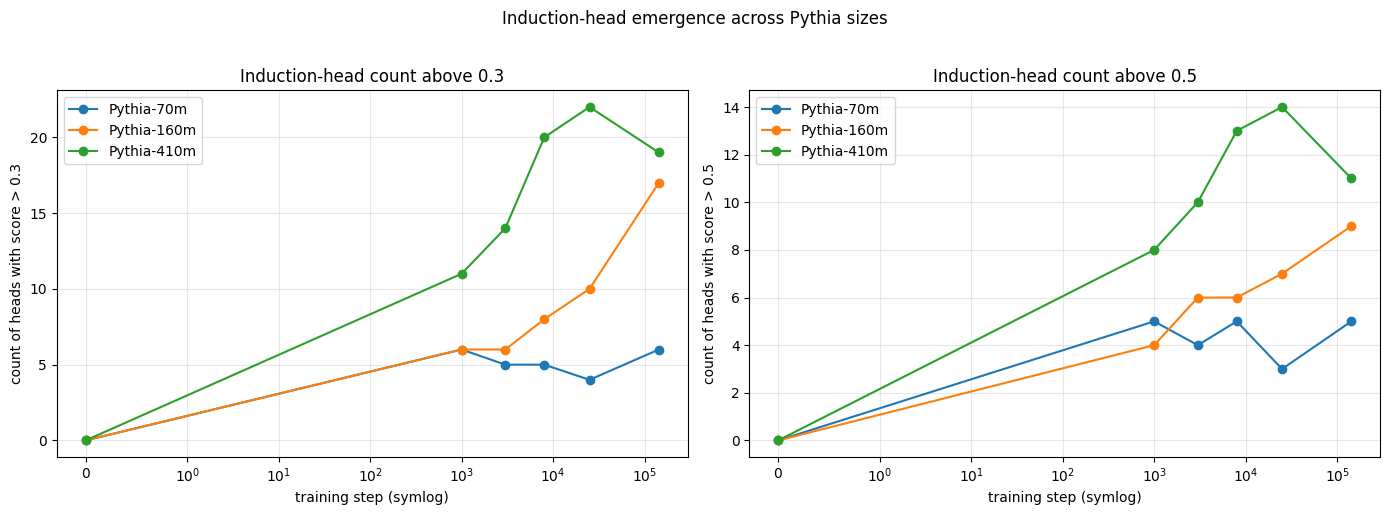

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
size_color = {'70m': 'tab:blue', '160m': 'tab:orange', '410m': 'tab:green'}
for ax, (col, thresh) in zip(
    axes,
    [('n_above_03', THRESHOLD_CANDIDATE), ('n_above_05', THRESHOLD_STRONG)],
):
    for size in SIZES:
        sub = counts[counts['size'] == size]
        ax.plot(sub['step'], sub[col], marker='o',
                color=size_color[size], label=f'Pythia-{size}')
    ax.set_xscale('symlog', linthresh=1)
    ax.set_xlabel('training step (symlog)')
    ax.set_ylabel(f'count of heads with score > {thresh}')
    ax.set_title(f'Induction-head count above {thresh}')
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle('Induction-head emergence across Pythia sizes', y=1.02)
plt.tight_layout()
plt.show()

Reading the curves:

- The y-axis is *count of heads*, not the strength of any one head. Both panels should rise from ~0 at step 0 to some saturated value by step 143000.
- The transition between near-zero and saturated is the **emergence window**. If the rise is steep, induction emerges as a phase transition; if gradual, it accumulates head-by-head over many steps.
- Comparing across sizes: do smaller models emerge earlier (in absolute step count) or later? The Olsson 2022 paper documents earlier emergence in smaller models for some scales — does this hold here too?

## Q1 quantified: estimate $\mu$ per size via logistic fit

Fit `count(step) ≈ L / (1 + exp(-k · (log(step) - μ)))` per size to the *candidate* count (threshold 0.3, more data points than 0.5). $\mu$ is the log-step at which count reaches half its final value — the operational definition of emergence step from `HYPOTHESIS.md`.

**Caveat:** with only 6 checkpoints per size, the logistic fit has very few degrees of freedom and is more anecdotal than rigorous. Phase 2's 40-point sweep is what gives this number actual statistical weight.

In [7]:
def logistic(log_step, L, k, mu):
    return L / (1.0 + np.exp(-k * (log_step - mu)))

fit_rows = []
for size in SIZES:
    sub = counts[counts['size'] == size].copy()
    log_steps = np.log(sub['step'].clip(lower=1).to_numpy())
    y = sub['n_above_03'].to_numpy().astype(float)
    if y.max() < 1:
        fit_rows.append({'size': size, 'L': float('nan'),
                         'k': float('nan'), 'mu_log': float('nan'),
                         'mu_step': float('nan')})
        continue
    p0 = (max(y.max(), 1.0), 1.0, np.median(log_steps))
    try:
        popt, _ = curve_fit(logistic, log_steps, y, p0=p0, maxfev=10000)
        L_fit, k_fit, mu_fit = popt
    except Exception as e:
        print(f'  fit failed for {size}: {e}')
        L_fit = k_fit = mu_fit = float('nan')
    fit_rows.append({'size': size, 'L': L_fit, 'k': k_fit,
                     'mu_log': mu_fit, 'mu_step': float(np.exp(mu_fit))})
fit_df = pd.DataFrame(fit_rows)
print(fit_df.to_string(index=False))

size             L         k    mu_log      mu_step
 70m      5.200000 14.758537  0.763503 2.145779e+00
160m 991939.538378  0.253678 55.197263 9.372745e+23
410m     20.909411  1.060120  6.936388 1.029046e+03


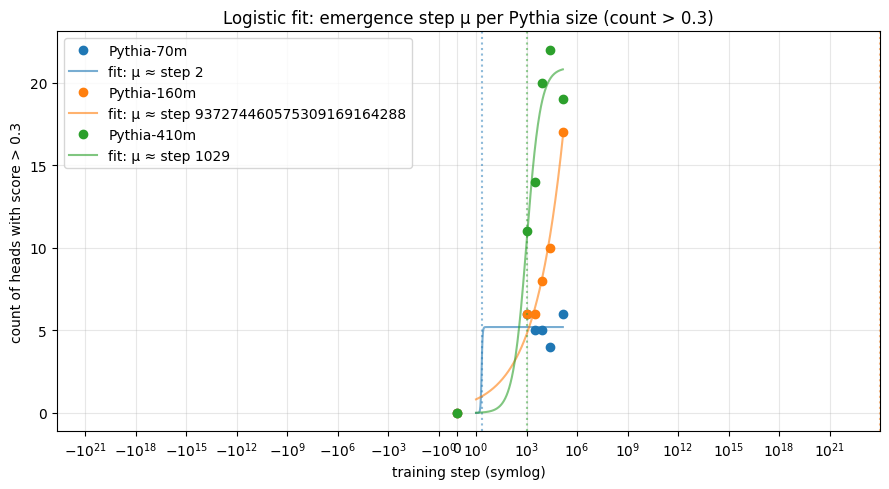

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
for size in SIZES:
    sub = counts[counts['size'] == size]
    ax.plot(sub['step'], sub['n_above_03'], 'o',
            color=size_color[size], label=f'Pythia-{size}')
    fit_row = fit_df[fit_df['size'] == size].iloc[0]
    if not np.isnan(fit_row['L']):
        log_grid = np.linspace(0, np.log(143000), 200)
        y_fit = logistic(log_grid, fit_row['L'], fit_row['k'],
                          fit_row['mu_log'])
        ax.plot(np.exp(log_grid), y_fit, '-',
                color=size_color[size], alpha=0.6,
                label=f'fit: μ ≈ step {fit_row["mu_step"]:.0f}')
        ax.axvline(fit_row['mu_step'], color=size_color[size],
                   linestyle=':', alpha=0.5)
ax.set_xscale('symlog', linthresh=1)
ax.set_xlabel('training step (symlog)')
ax.set_ylabel('count of heads with score > 0.3')
ax.set_title('Logistic fit: emergence step μ per Pythia size (count > 0.3)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Q3: do new induction heads stop appearing?

If the count saturates by some step `s*`, then `count(s*) ≈ count(143000)` for all later checkpoints. We measure how close the *penultimate* checkpoint is to the final, per size. Closer to 1.0 means the model has finished growing induction heads well before training ends; substantially less than 1.0 means new heads are still emerging late in training.

In [9]:
satur_rows = []
for size in SIZES:
    sub = counts[counts['size'] == size].sort_values('step')
    final = sub.iloc[-1]
    penult = sub.iloc[-2]
    halfway = sub.iloc[len(sub) // 2]
    satur_rows.append({
        'size': size,
        'count_final': int(final['n_above_03']),
        'count_penult': int(penult['n_above_03']),
        'penult_over_final': (
            float(penult['n_above_03']) / max(final['n_above_03'], 1)
        ),
        'count_halfway': int(halfway['n_above_03']),
        'halfway_over_final': (
            float(halfway['n_above_03']) / max(final['n_above_03'], 1)
        ),
        'penult_step': int(penult['step']),
        'halfway_step': int(halfway['step']),
    })
satur_df = pd.DataFrame(satur_rows)
print(satur_df.to_string(index=False))

size  count_final  count_penult  penult_over_final  count_halfway  halfway_over_final  penult_step  halfway_step
 70m            6             4           0.666667              5            0.833333        25000          8000
160m           17            10           0.588235              8            0.470588        25000          8000
410m           19            22           1.157895             20            1.052632        25000          8000


Reading the table:

- `penult_over_final` close to 1.0 → induction-head growth is essentially done by the penultimate checkpoint.
- `halfway_over_final` tells the same story for an earlier reference point.
- If both are near 1.0 across all sizes, the answer to Q3 is *yes, new heads stop emerging well before final*. If 410M trails 70M, larger models keep growing induction heads later.

Caveat: this 6-checkpoint preview gives a coarse picture. The Phase 2 sweep with denser late-training sampling will resolve whether saturation is sharp or there's a long tail of late-emerging weak induction heads.

## Bonus: where in the model do induction heads live?

Spatial-emergence heatmaps. For each size and checkpoint, color the `(layer, head)` grid by score. The pattern shows whether induction concentrates in specific layers and how that spatial distribution sharpens across training.

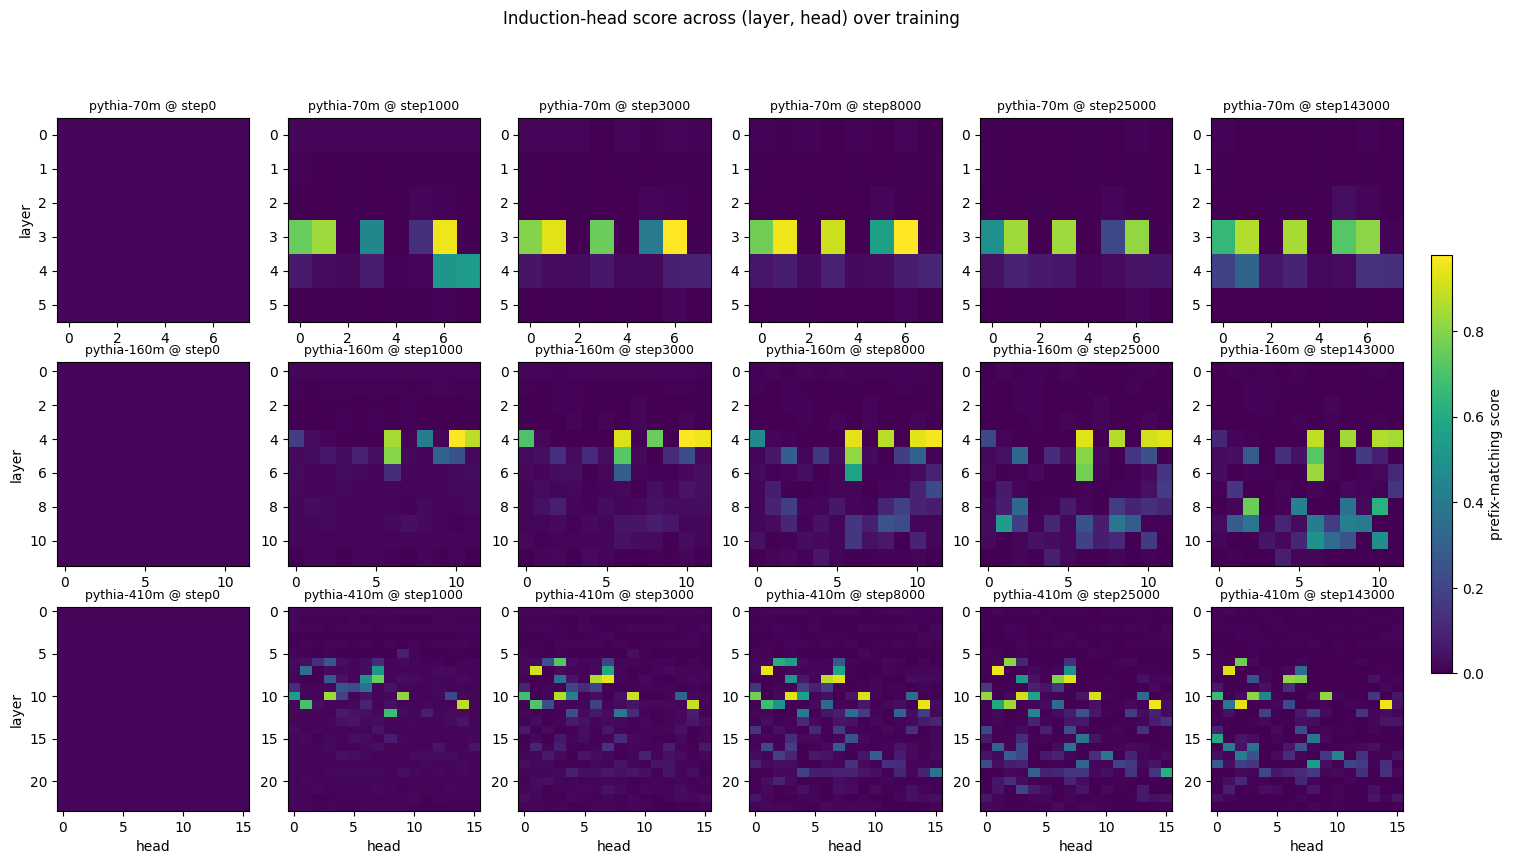

In [10]:
fig, axes = plt.subplots(
    nrows=len(SIZES), ncols=len(CHECKPOINTS),
    figsize=(3 * len(CHECKPOINTS), 3 * len(SIZES)),
)
vmax = float(df['score'].max())
for row, size in enumerate(SIZES):
    for col, step in enumerate(CHECKPOINTS):
        ax = axes[row][col]
        sub = df[(df['size'] == size) & (df['step'] == step)]
        n_layers = sub['layer'].max() + 1
        n_heads = sub['head'].max() + 1
        grid = np.zeros((n_layers, n_heads))
        for _, r in sub.iterrows():
            grid[int(r['layer']), int(r['head'])] = r['score']
        im = ax.imshow(grid, vmin=0, vmax=vmax, cmap='viridis', aspect='auto')
        ax.set_title(f'pythia-{size} @ step{step}', fontsize=9)
        if col == 0:
            ax.set_ylabel('layer')
        if row == len(SIZES) - 1:
            ax.set_xlabel('head')
fig.suptitle('Induction-head score across (layer, head) over training', y=1.0)
fig.colorbar(im, ax=axes, fraction=0.015, pad=0.02, label='prefix-matching score')
plt.show()

Reading the heatmap grid: rows are sizes, columns are checkpoints. Bright cells are induction heads. Watch for a sharp turn-on at one or two specific `(layer, head)` cells around the emergence step, vs a gradual brightening of multiple cells. The former would suggest a *circuit* discovery moment; the latter, gradual head-by-head accumulation.

Smaller models have fewer heads (smaller grids). 70M has 6 layers × 8 heads = 48 heads; 160M has 12 × 12 = 144; 410M has 24 × 16 = 384.

## Bonus: trajectories of the strongest final-checkpoint heads

Pick the top-3 heads (by final-checkpoint score) per size and plot their score across training. Does each head turn on at roughly the same step, or do they emerge sequentially?

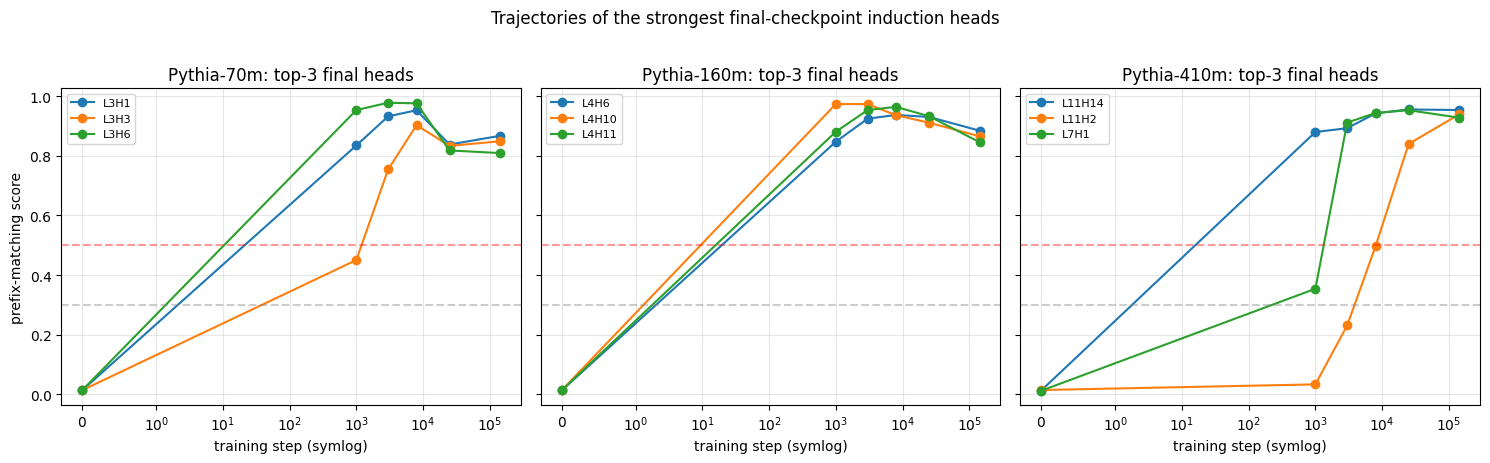

In [11]:
fig, axes = plt.subplots(1, len(SIZES), figsize=(15, 4.5), sharey=True)
for ax, size in zip(axes, SIZES):
    final = df[(df['size'] == size) & (df['step'] == 143000)]
    top3 = final.nlargest(3, 'score')[['layer', 'head']].values
    for layer, head in top3:
        traj = df[(df['size'] == size) & (df['layer'] == layer) & (df['head'] == head)]
        traj = traj.sort_values('step')
        ax.plot(traj['step'], traj['score'], marker='o',
                label=f'L{int(layer)}H{int(head)}')
    ax.set_xscale('symlog', linthresh=1)
    ax.set_xlabel('training step (symlog)')
    if size == SIZES[0]:
        ax.set_ylabel('prefix-matching score')
    ax.set_title(f'Pythia-{size}: top-3 final heads')
    ax.axhline(THRESHOLD_CANDIDATE, color='gray', linestyle='--', alpha=0.4)
    ax.axhline(THRESHOLD_STRONG, color='red', linestyle='--', alpha=0.4)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
fig.suptitle('Trajectories of the strongest final-checkpoint induction heads', y=1.02)
plt.tight_layout()
plt.show()

## Conclusions and open questions

From this 6-checkpoint preview:

- **Q1 (when):** the logistic fits give one estimate of μ per size. Take these with a large grain of salt — Phase 2's denser sampling is what produces a defensible number.
- **Q2 (how):** look at whether the curves are step-function-like (phase transition) or smoothly rising (gradual accumulation), and whether the trajectory plot shows simultaneous or sequential head turn-ons.
- **Q3 (when stop):** read the saturation table. If `penult_over_final` is near 1.0 across sizes, growth is essentially done well before final.

**Open questions** the Phase 2 sweep will resolve:

- What does the *shape* of the emergence curve look like at higher temporal resolution? With only 6 points, we can't distinguish a sharp phase transition from a smooth ramp.
- Does emergence step decrease, increase, or stay flat with model size?
- How much does the threshold choice (0.3 vs 0.5 vs 0.7) shift μ?

**Pre-registration discipline reminder:** results above are *exploratory*. They MUST NOT motivate a change to `HYPOTHESIS.md`'s ordering claim (induction → successor → suppression), since induction is the only motif this preview measures. Phase 2 will measure all three motifs with the registered schedule and analysis.